In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

### 1. LOAD & BASIC INSPECTION

In [2]:
df = pd.read_csv("Visadataset.csv")
print("Shape:", df.shape)
df.head()

# Summary statistics
df.describe()

# Check Null values and Dtypes
df.info()

Shape: (25480, 12)
<class 'pandas.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  str    
 1   continent              25480 non-null  str    
 2   education_of_employee  25480 non-null  str    
 3   has_job_experience     25480 non-null  str    
 4   requires_job_training  25480 non-null  str    
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  str    
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  str    
 10  full_time_position     25480 non-null  str    
 11  case_status            25480 non-null  str    
dtypes: float64(1), int64(2), str(9)
memory usage: 2.3 MB


### 2. MISSING VALUES


--- Missing Values ---
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


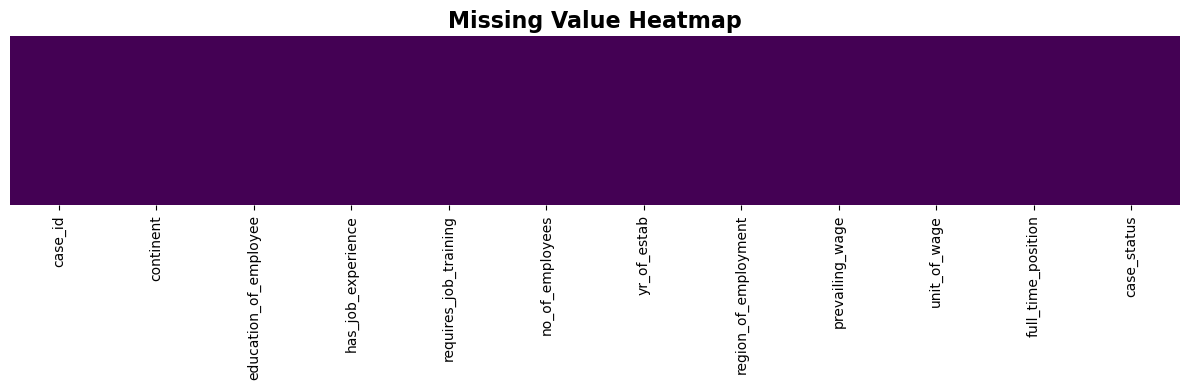

In [3]:
print("\n--- Missing Values ---")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

# Heatmap of missing values
plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Value Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 3. DEFINE FEATURE TYPES

In [4]:
# Convert to modern pandas dtypes
df = df.convert_dtypes()

numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['string']).columns.tolist()

print('Numerical features   ({}) : {}'.format(len(numeric_features), numeric_features))
print('Categorical features ({}) : {}'.format(len(categorical_features), categorical_features))

for col in categorical_features:
    print(f"\n{col}:\n", df[col].value_counts(normalize=True) * 100)
    print('---------------------------')

Numerical features   (3) : ['no_of_employees', 'yr_of_estab', 'prevailing_wage']
Categorical features (9) : ['case_id', 'continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'region_of_employment', 'unit_of_wage', 'full_time_position', 'case_status']

case_id:
 case_id
EZYV01       0.003925
EZYV02       0.003925
EZYV03       0.003925
EZYV04       0.003925
EZYV05       0.003925
               ...   
EZYV25476    0.003925
EZYV25477    0.003925
EZYV25478    0.003925
EZYV25479    0.003925
EZYV25480    0.003925
Name: proportion, Length: 25480, dtype: Float64
---------------------------

continent:
 continent
Asia             66.173469
Europe           14.646782
North America    12.919937
South America     3.343799
Africa             2.16248
Oceania           0.753532
Name: proportion, dtype: Float64
---------------------------

education_of_employee:
 education_of_employee
Bachelor's     40.164835
Master's       37.810047
High School    13.422292
Doctorate    

Insights
- `case_id`: unique per row → can be dropped (no predictive value).
- `continent`: heavily skewed towards Asia; other categories may be combined.
- `unit_of_wage`: most applicants are on yearly contracts.

### 4. DUPLICATE CHECK

In [5]:
print("\nDuplicate rows:", df.duplicated().sum())


Duplicate rows: 0


### 5. TARGET VARIABLE DISTRIBUTION

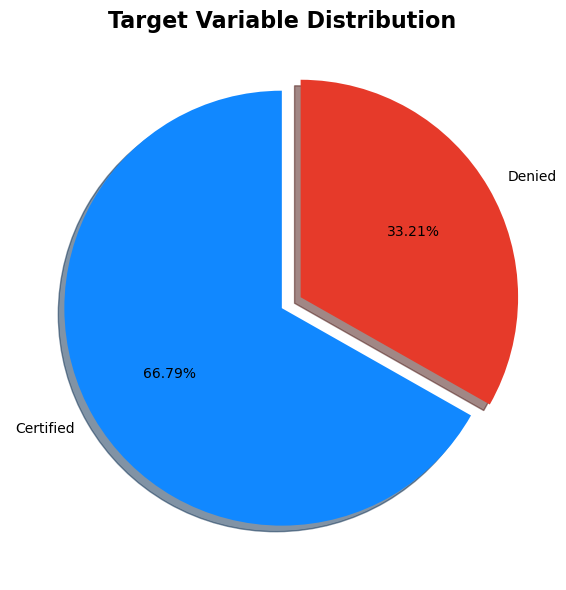

In [6]:
percentage = df['case_status'].value_counts(normalize=True) * 100
labels     = ["Certified", "Denied"]

fig, ax = plt.subplots(figsize=(8, 6))
explode = (0, 0.1)
colors  = ['#1188ff', '#e63a2a']
ax.pie(percentage, labels=labels, startangle=90,
       autopct='%1.2f%%', explode=explode, shadow=True, colors=colors)
plt.title('Target Variable Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

- The Target Variable (case_status) is imbalanced:
  - Certified ~66–67 % | Denied ~33 % (approximate; adjust after loading data)
- Imbalanced data means the minority class (Denied) has fewer observations.
  Techniques like SMOTE, class_weight, or oversampling may be required during modelling.

### 6. UNIVARIATE ANALYSIS – NUMERICAL

In [7]:
for feat in numeric_features:
    print(feat, df[feat].dtype, df[feat].head(3).tolist())

no_of_employees Int64 [14513, 2412, 44444]
yr_of_estab Int64 [2007, 2002, 2008]
prevailing_wage Float64 [592.2029, 83425.65, 122996.86]


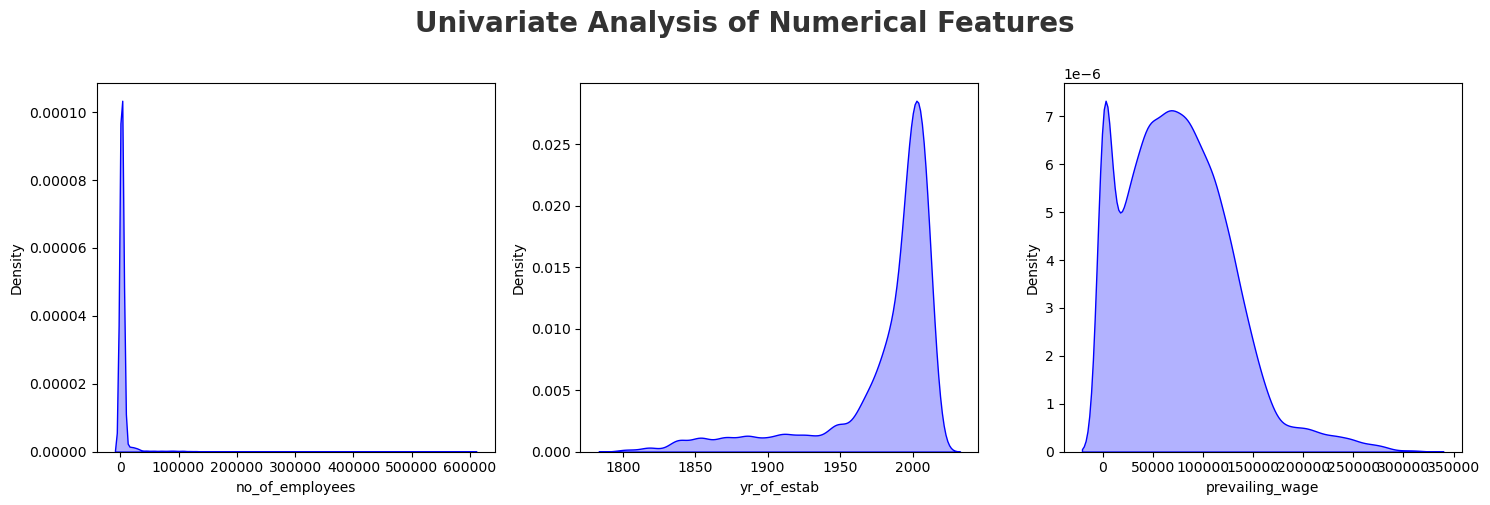

In [8]:
plt.figure(figsize=(15, 5))  # 1 row is enough for 3 features
plt.suptitle('Univariate Analysis of Numerical Features',
             fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i, feat in enumerate(numeric_features):
    plt.subplot(1, 3, i + 1)  # 1 row, 3 cols
    sns.kdeplot(x=df[feat], color='blue', fill=True, alpha=0.3)
    plt.xlabel(feat)
    plt.tight_layout()

plt.show()

Insights
- `no_of_employees` : heavily right-skewed; many outliers present.
- `yr_of_estab`     : discrete, left-skewed (most companies established recently).
- `prevailing_wage` : right-skewed distribution.

### 7. UNIVARIATE ANALYSIS – CATEGORICAL

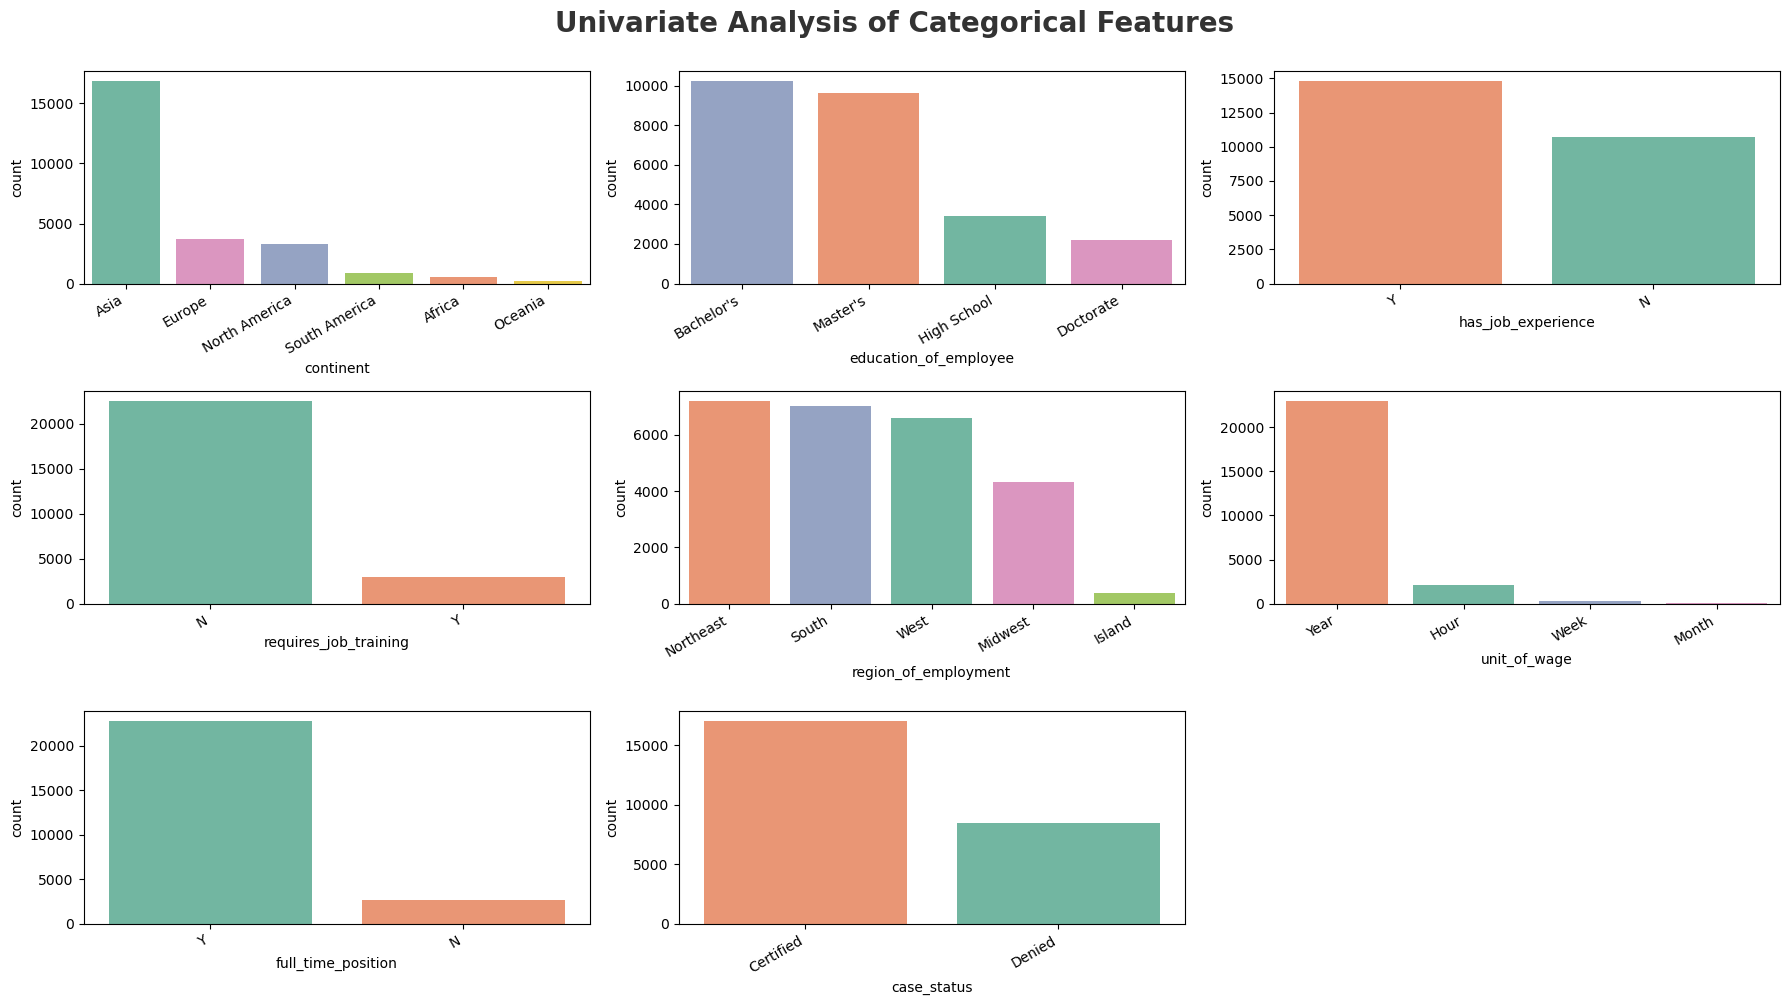

In [9]:
cat_plot_features = [f for f in categorical_features if f != 'case_id']

plt.figure(figsize=(18, 10))
plt.suptitle(
    'Univariate Analysis of Categorical Features',
    fontsize=20,
    fontweight='bold',
    alpha=0.8,
    y=1.
)

for i, col in enumerate(cat_plot_features):
    plt.subplot(3, 3, i + 1)

    order = df[col].value_counts().index

    sns.countplot(
        x=df[col],
        hue=df[col],
        order=order,
        palette='Set2',
        legend=False
    )

    plt.xlabel(col, fontsize=10)
    plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.show()

Insights
- `requires_job_training`, `unit_of_wage`, `full_time_position`, `continent`:
  single category dominates.
- Remaining columns are more balanced.

### 8. OUTLIER ANALYSIS


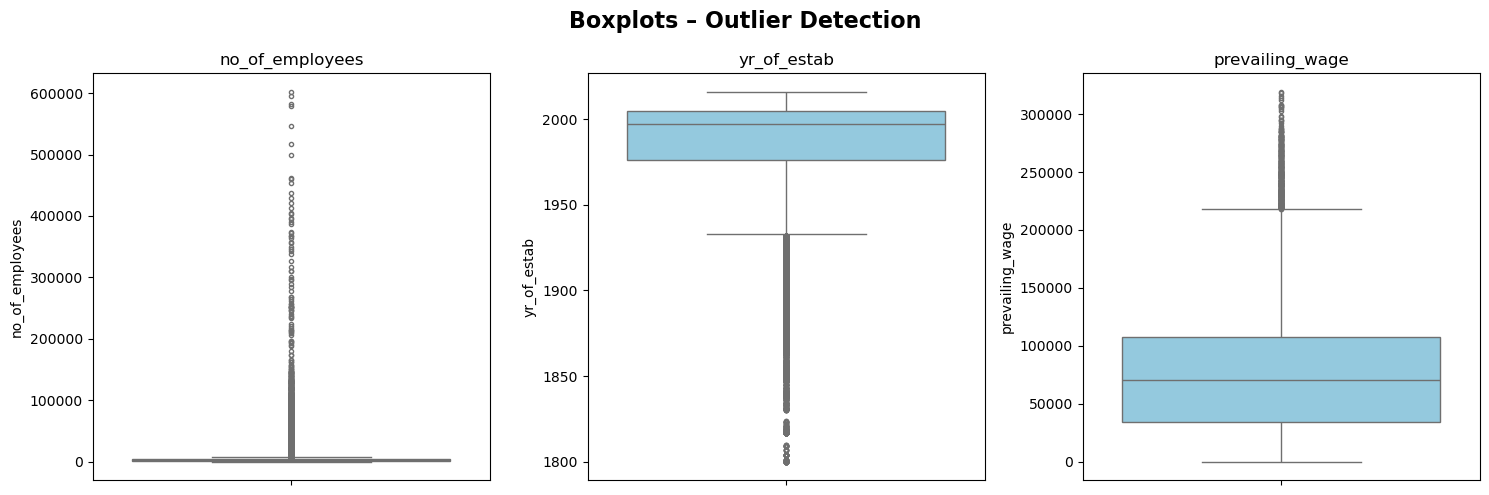


--- Outlier Counts (IQR method) ---
no_of_employees: 1556 outliers (6.11%)
yr_of_estab: 3260 outliers (12.79%)
prevailing_wage: 427 outliers (1.68%)


In [10]:
continuous_features = [f for f in numeric_features if len(df[f].unique()) > 25]

plt.figure(figsize=(15, 5))
plt.suptitle('Boxplots – Outlier Detection', fontsize=16, fontweight='bold')
for i, feat in enumerate(continuous_features):
    plt.subplot(1, len(continuous_features), i + 1)
    sns.boxplot(y=df[feat], color='skyblue', flierprops=dict(marker='o', color='red', markersize=3))
    plt.title(feat)
    plt.tight_layout()
plt.show()

# IQR-based outlier counts
print("\n--- Outlier Counts (IQR method) ---")
for feat in continuous_features:
    Q1, Q3 = df[feat].quantile(0.25), df[feat].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[feat] < Q1 - 1.5 * IQR) | (df[feat] > Q3 + 1.5 * IQR)]
    print(f"{feat}: {len(outliers)} outliers ({100*len(outliers)/len(df):.2f}%)")


### 9. MULTIVARIATE ANALYSIS

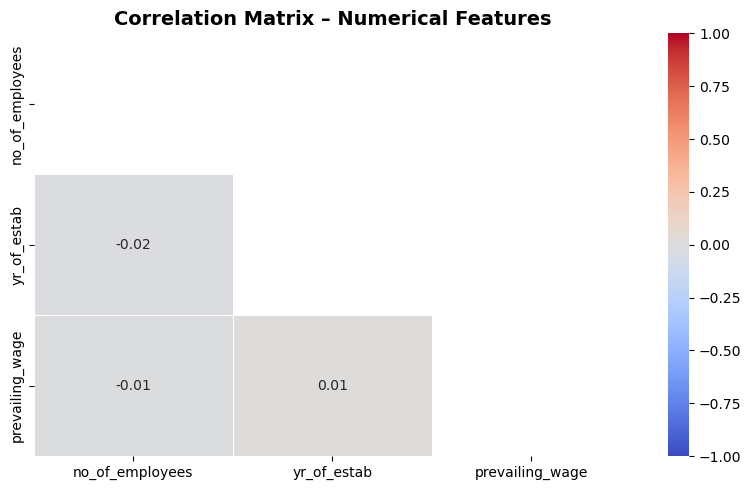

'\n* Correlation between numerical features indicates potential multicollinearity.\n  Features with |correlation| > 0.7 should be handled during feature selection.\n'

In [11]:
# 9a. Correlation Heatmap (Numerical)
plt.figure(figsize=(8, 5))
corr = df[numeric_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix – Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

"""
* Correlation between numerical features indicates potential multicollinearity.
  Features with |correlation| > 0.7 should be handled during feature selection.
"""

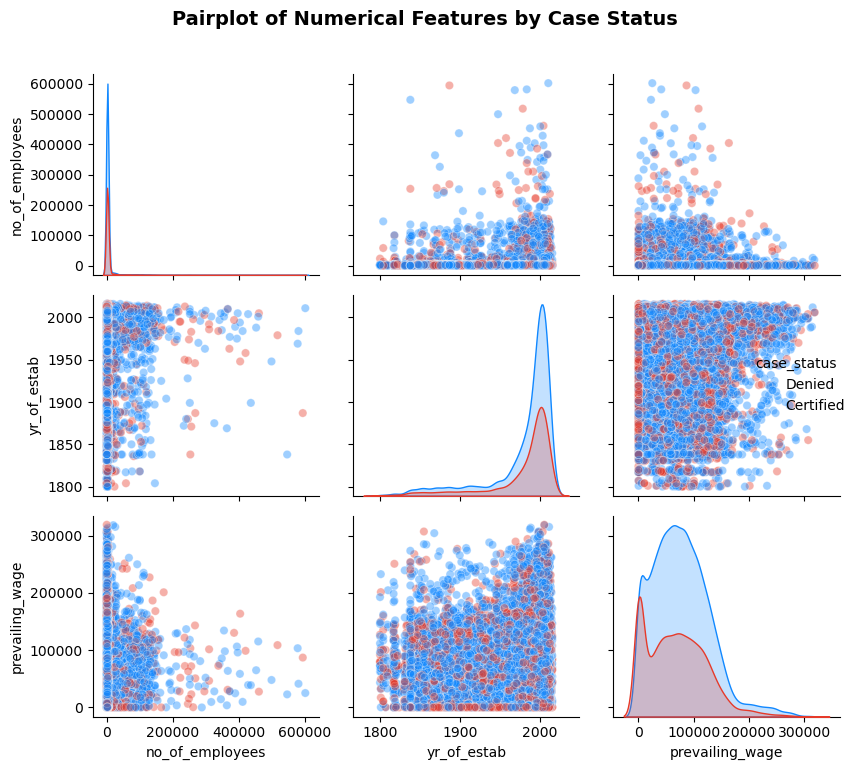

In [12]:
# 9b. Pairplot (Numerical + Target)
sns.pairplot(df[numeric_features + ['case_status']], hue='case_status',
             palette={'Certified': '#1188ff', 'Denied': '#e63a2a'},
             diag_kind='kde', plot_kws={'alpha': 0.4})
plt.suptitle('Pairplot of Numerical Features by Case Status', y=1.02,
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

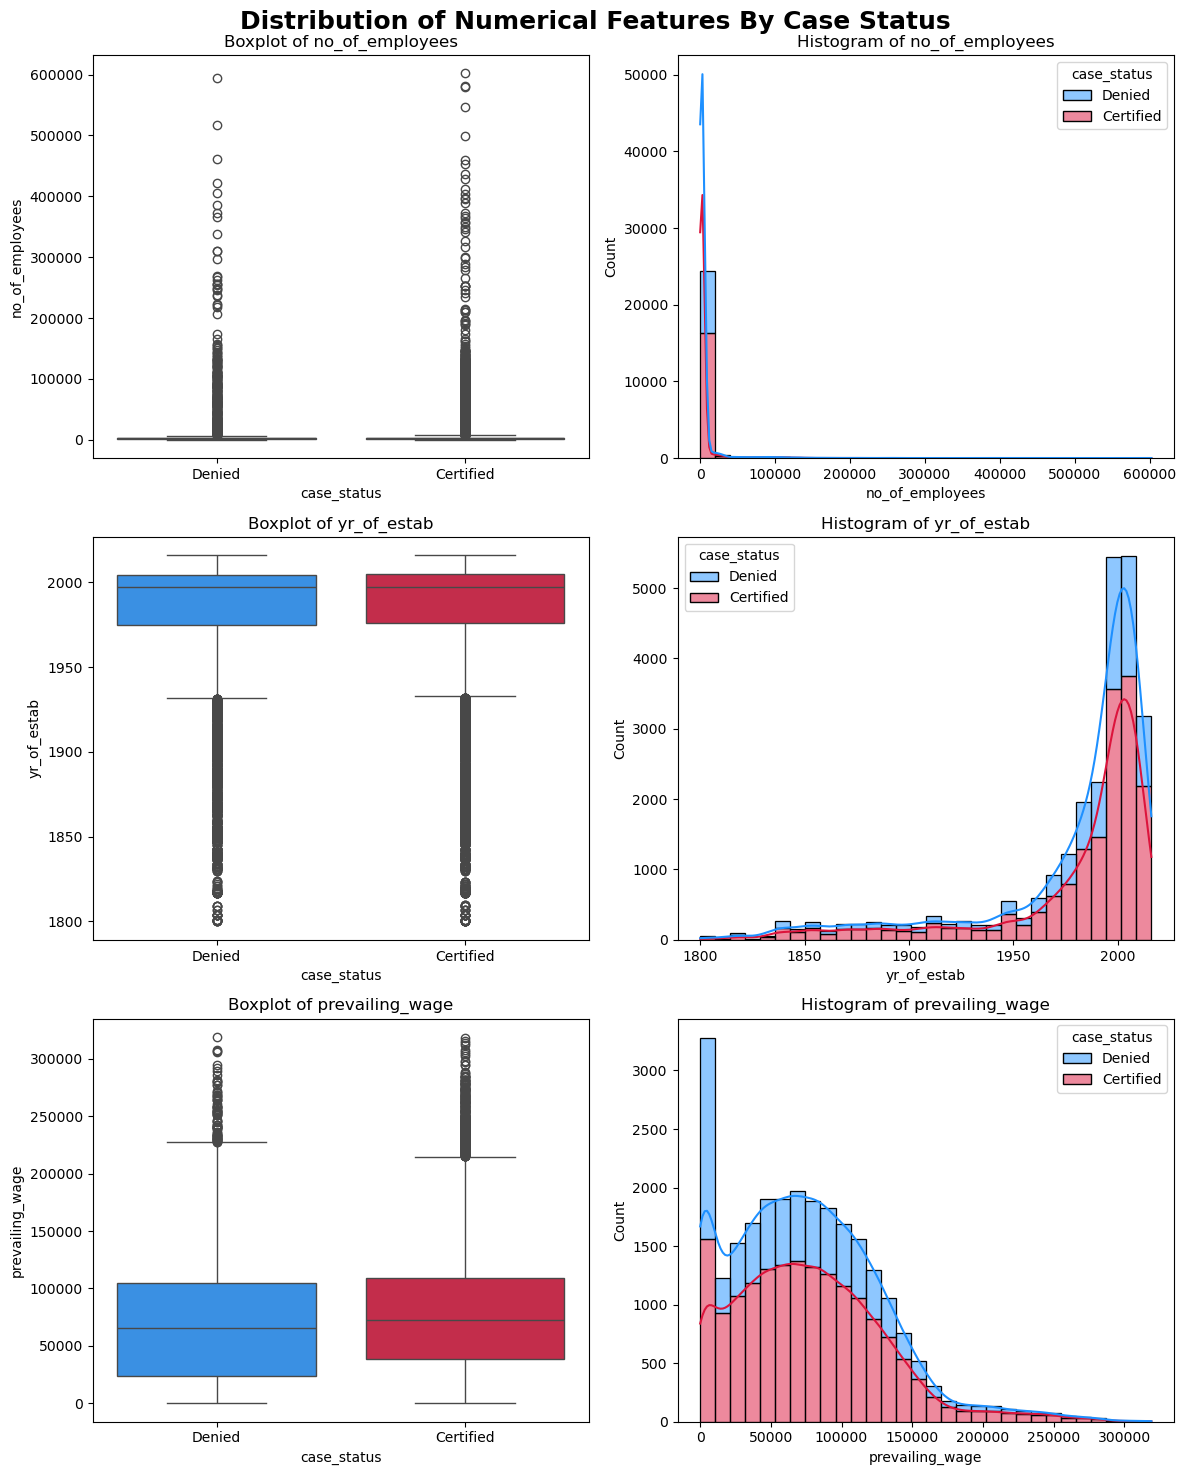

In [13]:
clr1 = ['#1E90FF', '#DC143C']

fig, ax = plt.subplots(
    len(continuous_features),
    2,
    figsize=(12, 5 * len(continuous_features))
)

fig.suptitle(
    'Distribution of Numerical Features By Case Status',
    fontsize=18,
    fontweight='bold',
    ha='center'
)

for i, col in enumerate(continuous_features):

    # Boxplot
    sns.boxplot(
        data=df,
        x='case_status',
        y=col,
        hue='case_status',
        palette=clr1,
        legend=False,
        ax=ax[i, 0]
    )
    ax[i, 0].set_title(f'Boxplot of {col}', fontsize=12)

    # Histogram
    sns.histplot(
        data=df,
        x=col,
        hue='case_status',
        bins=30,
        kde=True,
        multiple='stack',
        palette=clr1,
        ax=ax[i, 1]
    )
    ax[i, 1].set_title(f'Histogram of {col}', fontsize=12)

fig.tight_layout()
fig.subplots_adjust(top=0.95)
plt.show()

Initial Analysis Report
- `no_of_employees` has many outliers; right-skewed → log/sqrt transform recommended.
- `yr_of_estab` is left-skewed; a few outliers below the lower bound.
- `prevailing_wage` is right-skewed with extreme outliers → log transform recommended.
- No missing values found in the dataset.
- `case_id` can be dropped (unique per row, no predictive value).
- `case_status` is the target column.

### 10. CHI-SQUARE TEST (Categorical vs Target)

In [14]:
cat_test_features = [f for f in categorical_features if f not in ('case_id', 'case_status')]
chi2_results = []
for feature in cat_test_features:
    p_val = chi2_contingency(pd.crosstab(df['case_status'], df[feature]))[1]
    decision = 'Reject H₀ (significant)' if p_val < 0.05 else 'Fail to Reject H₀'
    chi2_results.append({'Column': feature, 'p-value': round(p_val, 4), 'Result': decision})

chi2_df = pd.DataFrame(chi2_results)
print("\n--- Chi-Square Test: Categorical vs case_status ---")
print(chi2_df.to_string(index=False))


--- Chi-Square Test: Categorical vs case_status ---
               Column  p-value                  Result
            continent   0.0000 Reject H₀ (significant)
education_of_employee   0.0000 Reject H₀ (significant)
   has_job_experience   0.0000 Reject H₀ (significant)
requires_job_training   0.1856       Fail to Reject H₀
 region_of_employment   0.0000 Reject H₀ (significant)
         unit_of_wage   0.0000 Reject H₀ (significant)
   full_time_position   0.0447 Reject H₀ (significant)


Report
- `requires_job_training` fails to reject H₀ → not significantly correlated with target.
- All other categorical features show significant association with case_status.

### 11. BIVARIATE – CATEGORICAL vs TARGET

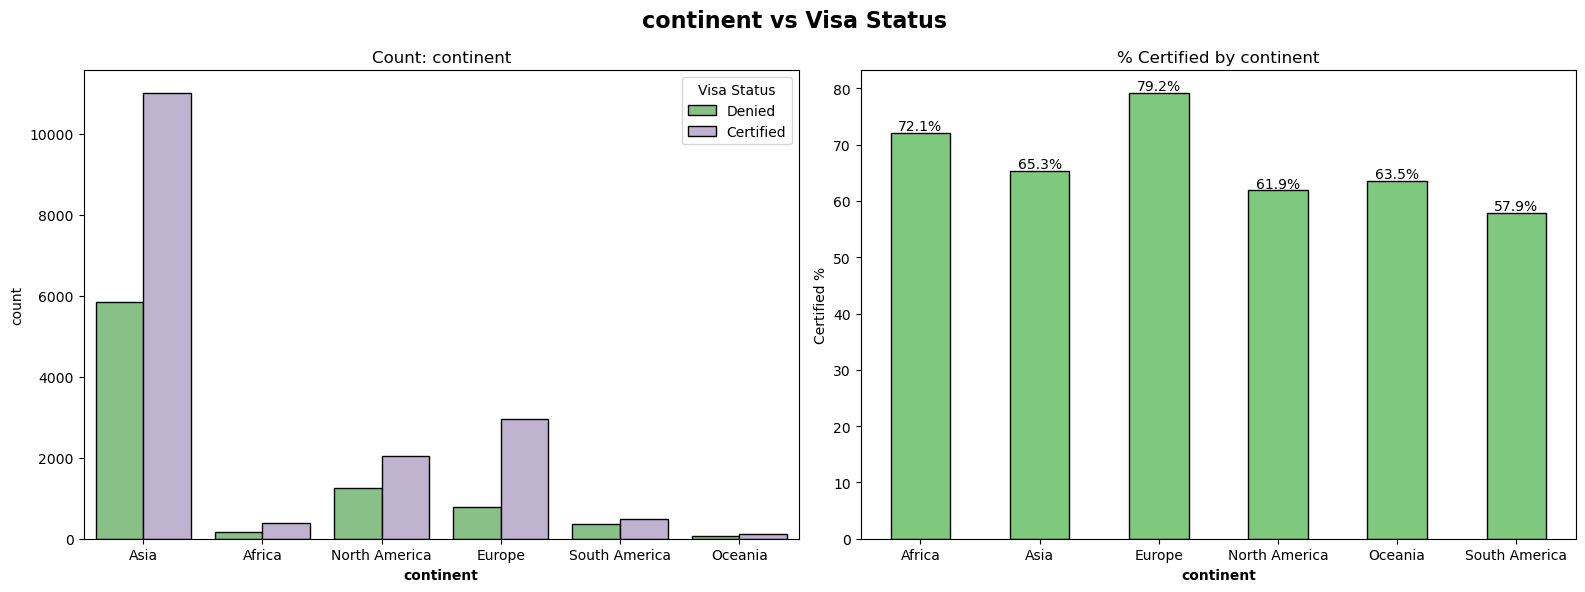

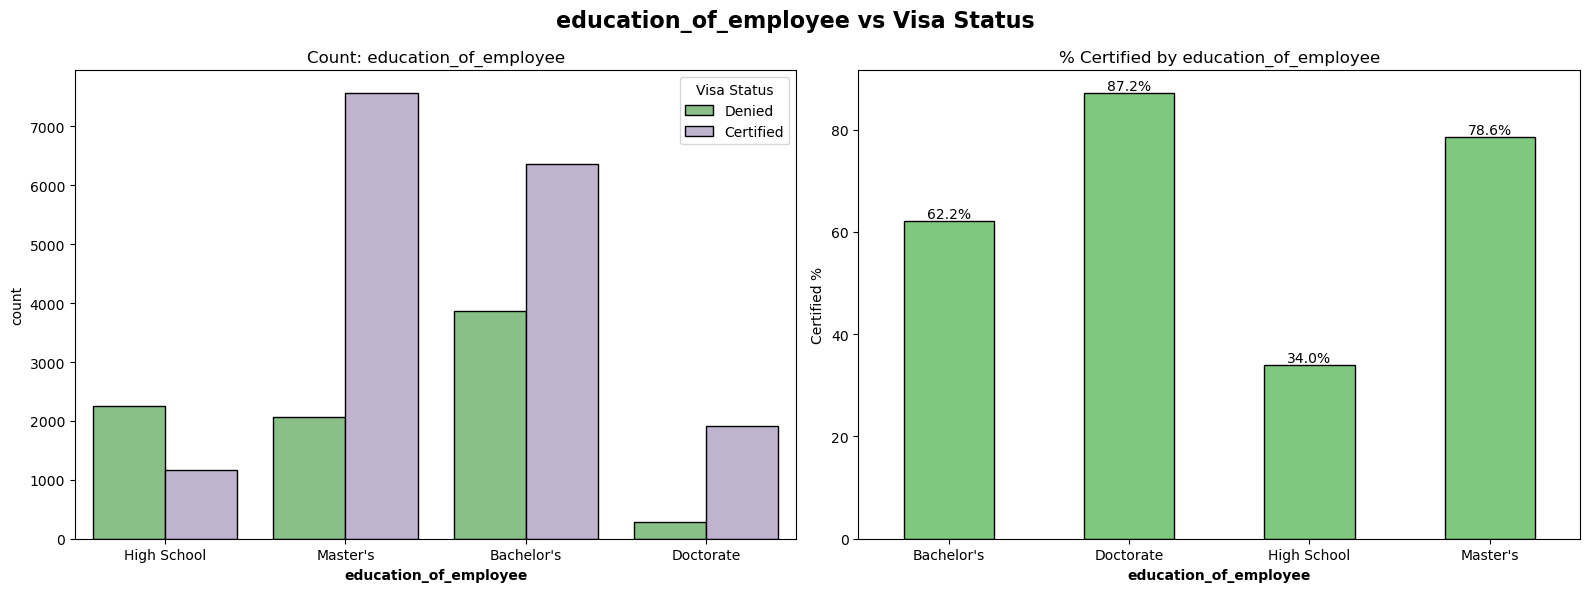

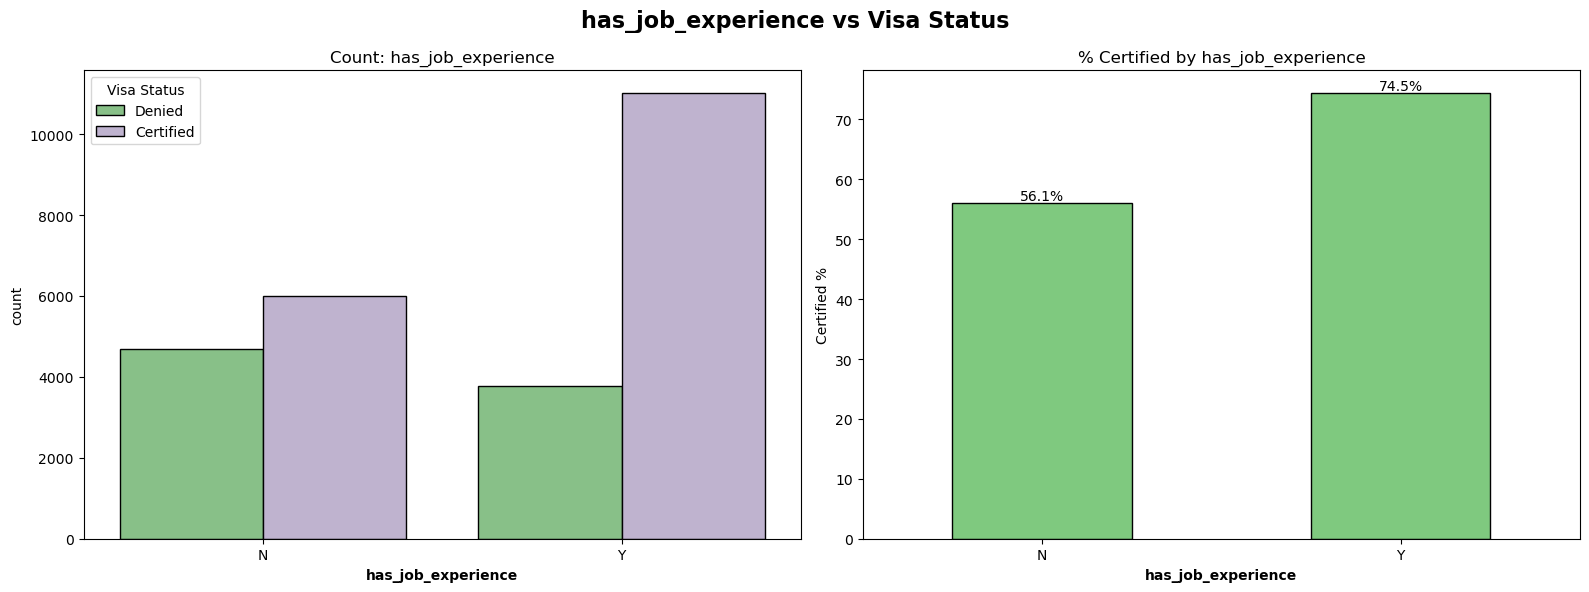

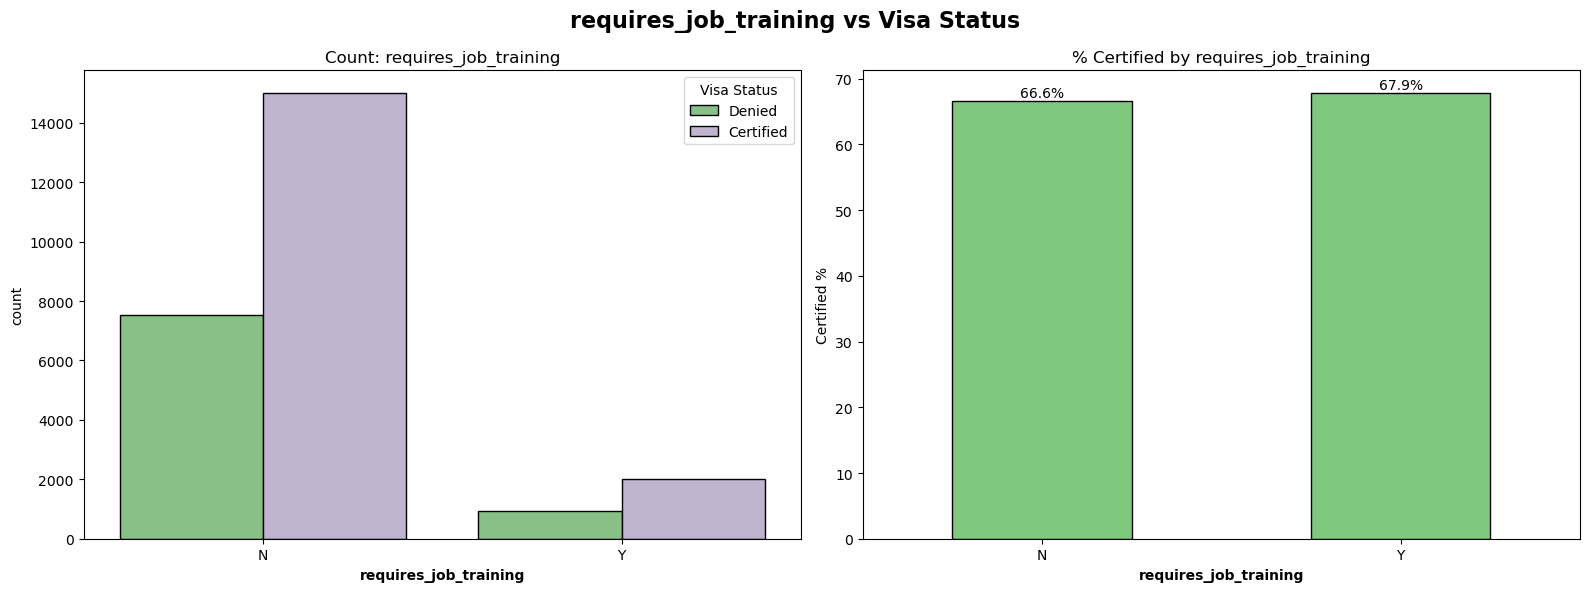

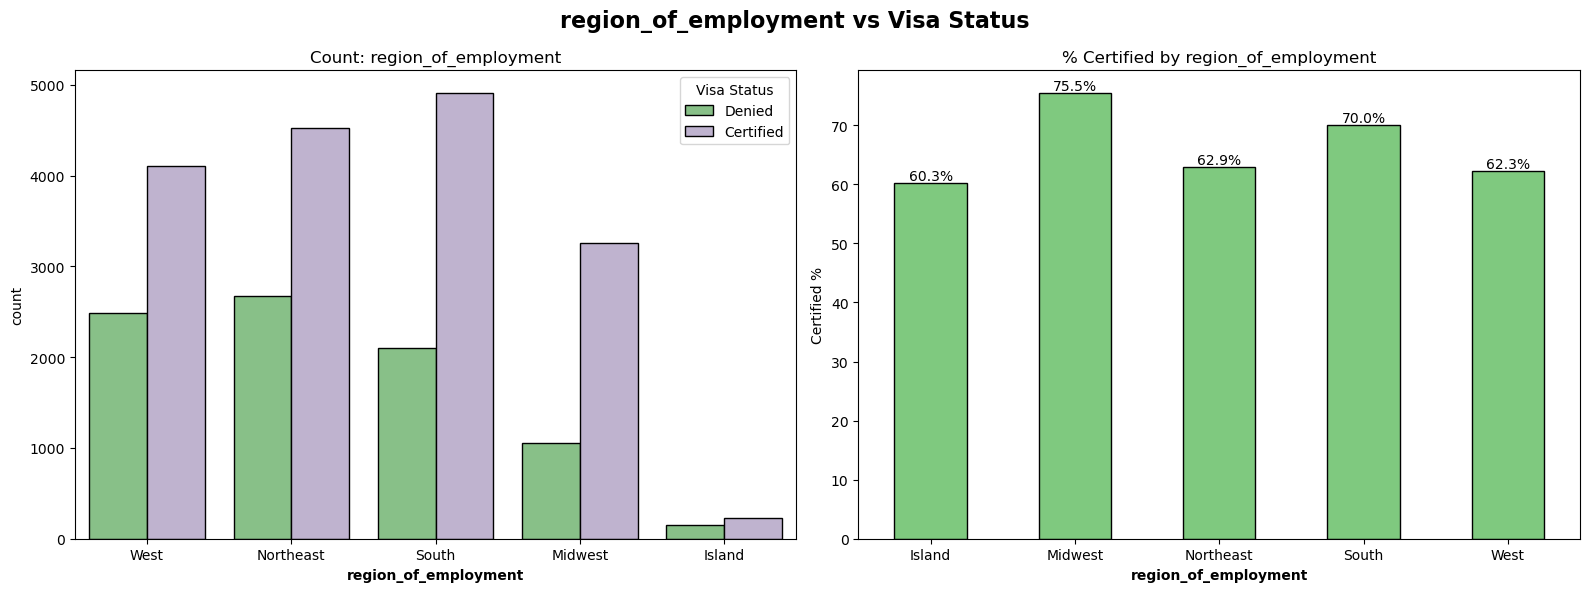

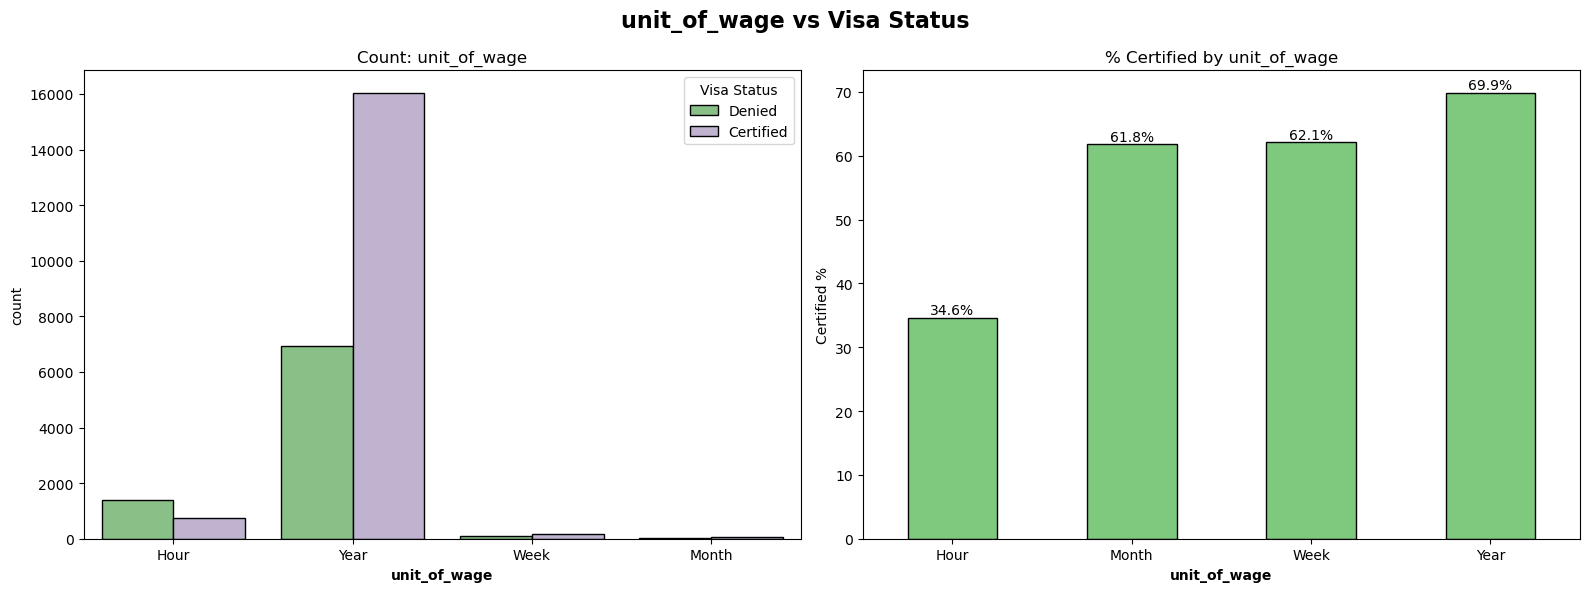

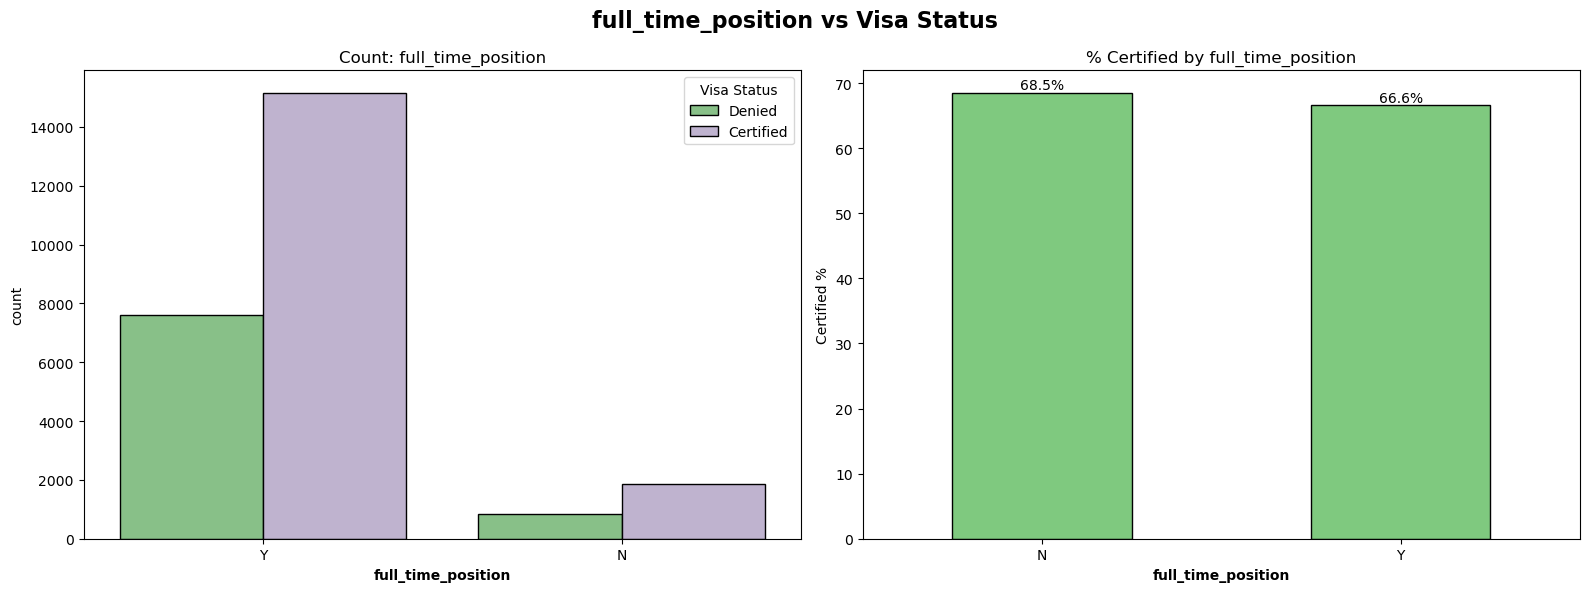

In [15]:
df2 = df.copy()

def bivariate_cat_plot(col, df2):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'{col} vs Visa Status', fontsize=16, fontweight='bold')

    # Count plot
    sns.countplot(x=col, hue='case_status', data=df2,
                  ec='black', palette='Accent', ax=axes[0])
    axes[0].set_title(f'Count: {col}')
    axes[0].set_xlabel(col, fontweight='bold')
    axes[0].legend(title='Visa Status')

    # Certified %
    cert_pct = (100 * df2[df2['case_status'] == 'Certified'][col].value_counts()
                / df2[col].value_counts()).sort_index()
    cert_pct.plot(kind='bar', ax=axes[1], colormap='Accent', edgecolor='black')
    axes[1].set_title(f'% Certified by {col}')
    axes[1].set_xlabel(col, fontweight='bold')
    axes[1].set_ylabel('Certified %')
    for n, v in enumerate(cert_pct):
        axes[1].text(n, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10)

    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

for col in cat_test_features:
    bivariate_cat_plot(col, df2)

### 12. CONTINENT ANALYSIS 

In [16]:
print("\n--- Continent vs Case Status (%) ---")
print(df.groupby('continent')['case_status'].value_counts(normalize=True).unstack() * 100)



--- Continent vs Case Status (%) ---
case_status    Certified     Denied
continent                          
Africa         72.050817  27.949183
Asia           65.310480  34.689520
Europe         79.233655  20.766345
North America  61.877278  38.122722
Oceania        63.541667  36.458333
South America  57.863850  42.136150


### 13. WAGE ANALYSIS

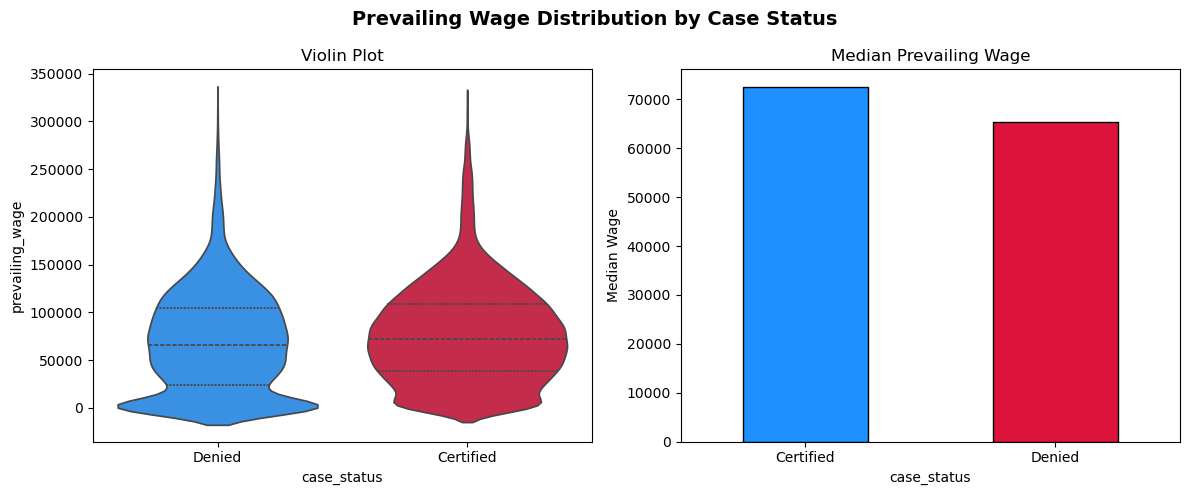

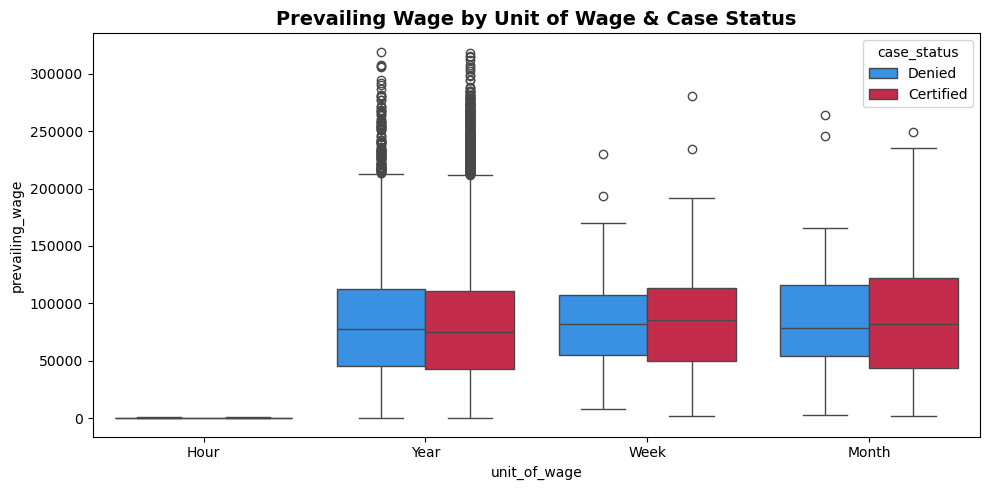

In [17]:
plt.figure(figsize=(12, 5))
plt.suptitle(
    'Prevailing Wage Distribution by Case Status',
    fontsize=14,
    fontweight='bold'
)

# Violin Plot
plt.subplot(1, 2, 1)
sns.violinplot(
    data=df,
    x='case_status',
    y='prevailing_wage',
    hue='case_status',
    palette=['#1E90FF', '#DC143C'],
    inner='quartile',
    legend=False
)
plt.title('Violin Plot')

# Median Bar Plot
plt.subplot(1, 2, 2)
df.groupby('case_status')['prevailing_wage'].median().plot(
    kind='bar',
    color=['#1E90FF', '#DC143C'],
    edgecolor='black'
)
plt.title('Median Prevailing Wage')
plt.ylabel('Median Wage')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


# Wage by unit_of_wage
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df,
    x='unit_of_wage',
    y='prevailing_wage',
    hue='case_status',
    palette=['#1E90FF', '#DC143C']
)

plt.title(
    'Prevailing Wage by Unit of Wage & Case Status',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

Insights – Wage Analysis
- Certified applicants tend to have higher prevailing wages.
- Yearly wage contracts dominate and show higher certification rates.

### 14. COMPANY AGE ANALYSIS

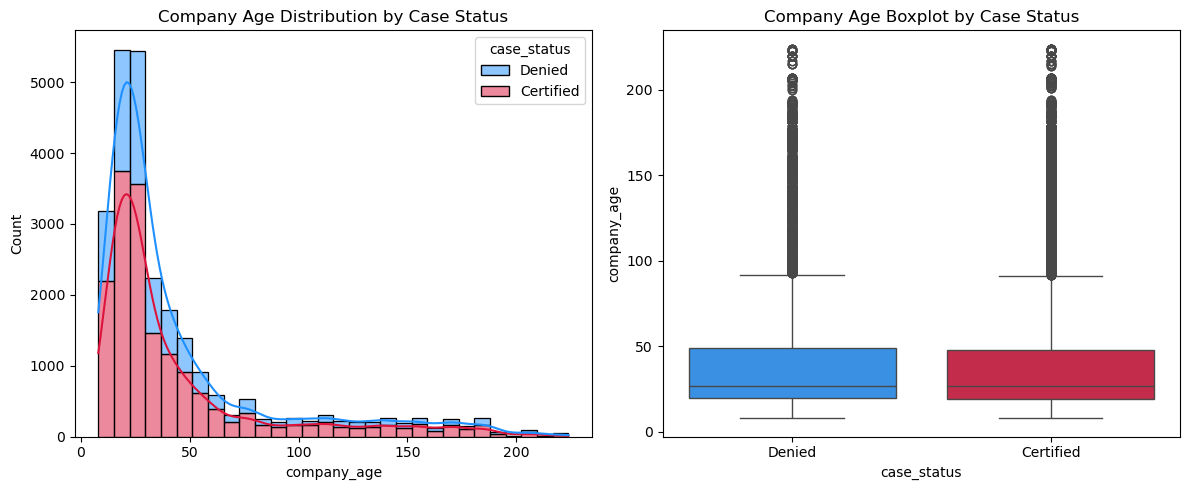

In [18]:
df2['company_age'] = 2024 - df2['yr_of_estab']

plt.figure(figsize=(12, 5))

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(
    data=df2,
    x='company_age',
    hue='case_status',
    kde=True,
    bins=30,
    palette=['#1E90FF', '#DC143C'],
    multiple='stack'
)
plt.title('Company Age Distribution by Case Status')

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(
    data=df2,
    x='case_status',
    y='company_age',
    hue='case_status',
    palette=['#1E90FF', '#DC143C'],
    legend=False
)
plt.title('Company Age Boxplot by Case Status')

plt.tight_layout()
plt.show()

Insights – Company Age
- Applications from older companies tend to have a slightly higher certification rate.
- Very recently established companies show lower certification rates.

### 15. FULL TIME POSITION vs VISA STATUS

<Figure size 800x500 with 0 Axes>

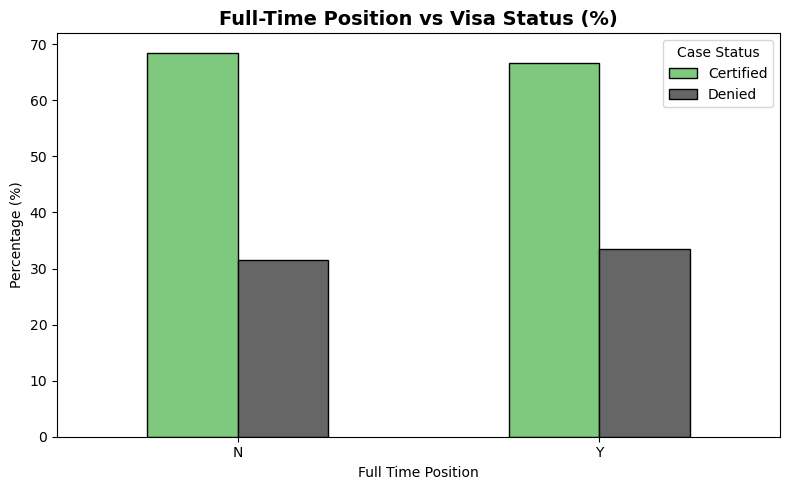

In [19]:
plt.figure(figsize=(8, 5))
ct = pd.crosstab(df['full_time_position'], df['case_status'], normalize='index') * 100
ct.plot(kind='bar', colormap='Accent', edgecolor='black', figsize=(8, 5))
plt.title('Full-Time Position vs Visa Status (%)', fontsize=14, fontweight='bold')
plt.ylabel('Percentage (%)')
plt.xlabel('Full Time Position')
plt.xticks(rotation=0)
plt.legend(title='Case Status')
plt.tight_layout()
plt.show()

Insights – Full Time Position
- Full-time positions have a higher certification rate than part-time positions.


### 16. NO OF EMPLOYEES vs VISA STATUS


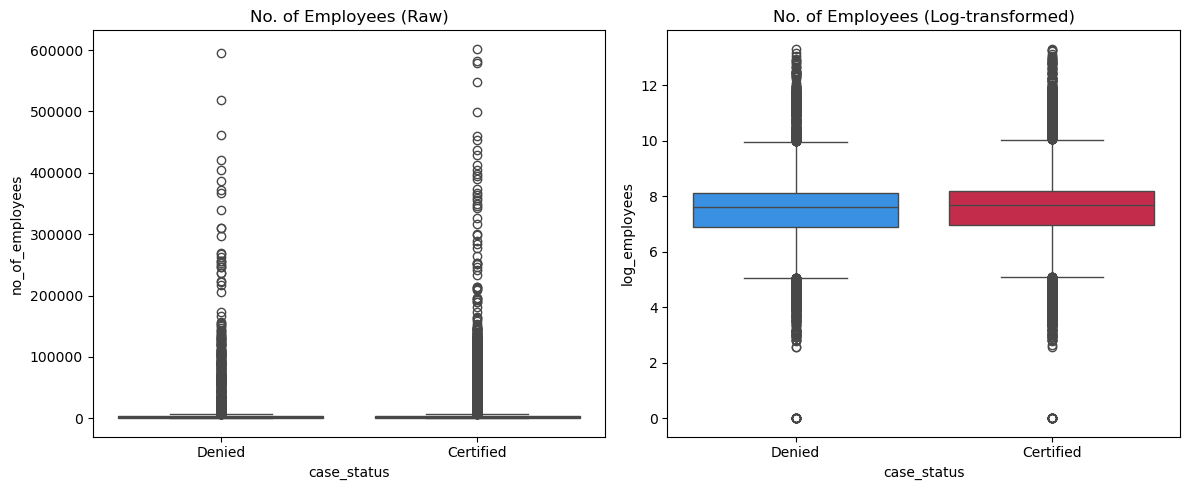

In [20]:
# log transform
df2['log_employees'] = np.log1p(
    df2['no_of_employees'].clip(lower=0)
)

plt.figure(figsize=(12, 5))

# Raw
plt.subplot(1, 2, 1)
sns.boxplot(
    data=df2,
    x='case_status',
    y='no_of_employees',
    hue='case_status',
    palette=['#1E90FF', '#DC143C'],
    legend=False
)
plt.title('No. of Employees (Raw)')

# Log
plt.subplot(1, 2, 2)
sns.boxplot(
    data=df2,
    x='case_status',
    y='log_employees',
    hue='case_status',
    palette=['#1E90FF', '#DC143C'],
    legend=False
)
plt.title('No. of Employees (Log-transformed)')

plt.tight_layout()
plt.show()

Insights
- After log transformation, the distribution is more interpretable.
- Larger companies seem to have a slightly higher certification rate.


### 17. FINAL SUMMARY REPORT

In [21]:
print("""
=======================================================
          FINAL EDA SUMMARY REPORT – VISA DATASET
=======================================================

DATASET OVERVIEW
- No missing values detected.
- case_id is unique per row → drop before modelling.
- Target variable: case_status (Certified / Denied) – IMBALANCED.

KEY FINDINGS
1. Target Imbalance : ~66% Certified, ~34% Denied.
   Action → Use SMOTE, class_weight, or oversampling.

2. Continent : Asia dominates applications; Europe & Africa
   have the highest certification rates proportionally.

3. Education : Doctorate & Master's holders have significantly
   higher certification rates.

4. Job Experience : Applicants WITH prior experience are more
   likely to be certified.

5. Job Training : requires_job_training is NOT significantly
   correlated with visa status (Chi-square p > 0.05).

6. Unit of Wage : Yearly contracts dominate and show the
   highest certification proportion.

7. Prevailing Wage : Certified applicants tend to earn more;
   right-skewed → log transform recommended.

8. No. of Employees : Right-skewed with many outliers →
   log transform / capping recommended.

9. Company Age (derived) : Older companies show marginally
   better certification rates.

10. Full-Time Position : Full-time roles certified more often
    than part-time roles.

FEATURE ENGINEERING SUGGESTIONS
- Drop : case_id
- Create : company_age = 2024 - yr_of_estab
- Encode : Binary columns (Y/N) → 0/1
- Log Transform : no_of_employees, prevailing_wage
- Combine rare categories : continent (non-Asia → 'Other')
- Handle Imbalance : SMOTE or class_weight in models
=======================================================
""")


          FINAL EDA SUMMARY REPORT – VISA DATASET

DATASET OVERVIEW
- No missing values detected.
- case_id is unique per row → drop before modelling.
- Target variable: case_status (Certified / Denied) – IMBALANCED.

KEY FINDINGS
1. Target Imbalance : ~66% Certified, ~34% Denied.
   Action → Use SMOTE, class_weight, or oversampling.

2. Continent : Asia dominates applications; Europe & Africa
   have the highest certification rates proportionally.

3. Education : Doctorate & Master's holders have significantly
   higher certification rates.

4. Job Experience : Applicants WITH prior experience are more
   likely to be certified.

5. Job Training : requires_job_training is NOT significantly
   correlated with visa status (Chi-square p > 0.05).

6. Unit of Wage : Yearly contracts dominate and show the
   highest certification proportion.

7. Prevailing Wage : Certified applicants tend to earn more;
   right-skewed → log transform recommended.

8. No. of Employees : Right-skewed with ma